<a href="https://colab.research.google.com/github/kavya5cloud/dark-universe-lab/blob/main/01_GaussianRandomFields.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter

plt.rcParams["figure.figsize"] = (8,8)

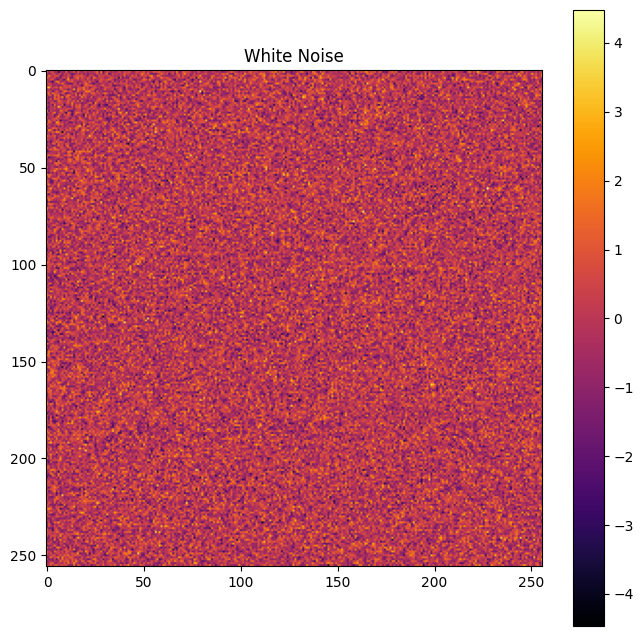

In [2]:
np.random.seed(42)

white_noise = np.random.normal(
    0,
    1,
    (256,256)
)

plt.imshow(white_noise, cmap="inferno")
plt.colorbar()
plt.title("White Noise")
plt.show()

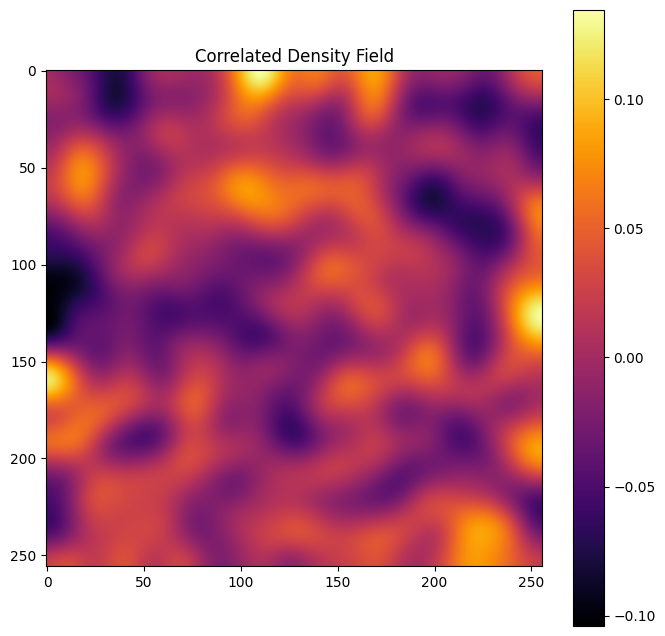

In [13]:
density_field = gaussian_filter(
    white_noise,
    sigma=10
)

plt.imshow(density_field, cmap="inferno")
plt.colorbar()
plt.title("Correlated Density Field")
plt.show()

In [4]:
density_field = (
    density_field - density_field.mean()
) / density_field.std()

print("Mean:", density_field.mean())
print("Std:", density_field.std())

Mean: -1.3877787807814457e-17
Std: 0.9999999999999999


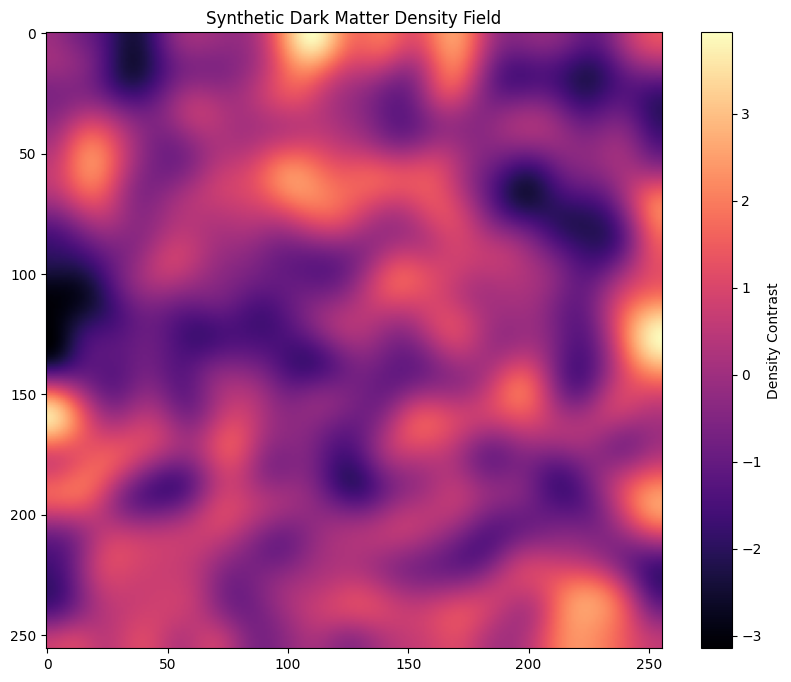

In [5]:
plt.figure(figsize=(10,8))

plt.imshow(
    density_field,
    cmap="magma"
)

plt.colorbar(label="Density Contrast")
plt.title("Synthetic Dark Matter Density Field")

plt.show()

In [6]:
fft_field = np.fft.fft2(density_field)

print(fft_field.shape)

(256, 256)


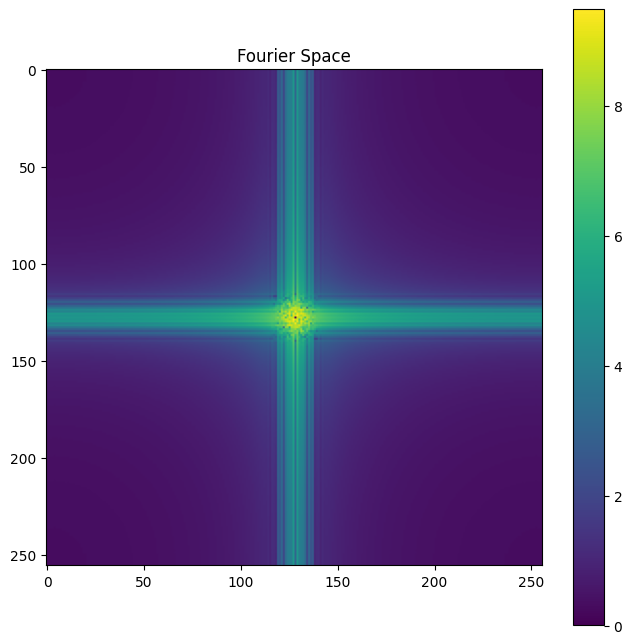

In [7]:
fft_shifted = np.fft.fftshift(
    np.abs(fft_field)
)

plt.imshow(
    np.log1p(fft_shifted),
    cmap="viridis"
)

plt.colorbar()
plt.title("Fourier Space")
plt.show()

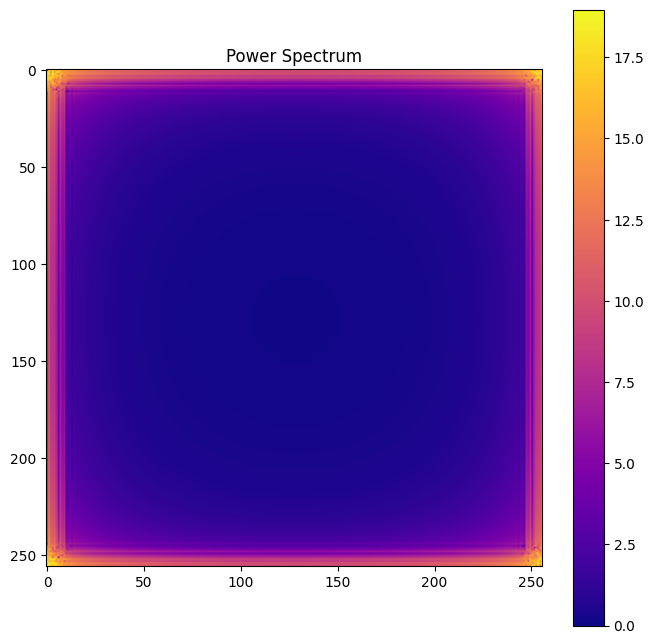

In [8]:
power_spectrum = np.abs(
    fft_field
)**2

plt.imshow(
    np.log1p(power_spectrum),
    cmap="plasma"
)

plt.colorbar()
plt.title("Power Spectrum")
plt.show()